In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv", index_col=0)

In [3]:
train_data.head(10)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
5,Sandy,5.09,24.70,1.28,0.48,12.21,92.35,696.03,9.11,7.37,Sugarcane,Flowering,Kharif,Sprinkler,River,0.81,No,86.56,South,Medium
6,Silt,7.53,49.67,1.44,1.62,14.02,61.65,889.39,8.44,16.76,Potato,Flowering,Zaid,Sprinkler,Rainwater,13.32,No,14.05,East,Medium
7,Loamy,7.56,48.61,0.38,1.31,22.78,61.53,708.82,9.96,7.83,Rice,Sowing,Zaid,Sprinkler,Reservoir,5.63,Yes,110.99,East,Low
8,Silt,6.02,53.01,0.90,0.49,20.55,61.30,1536.36,10.50,19.38,Potato,Flowering,Kharif,Rainfed,River,8.17,Yes,36.37,West,Low


In [4]:
train_data.shape

(630000, 20)

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Water_Sou

In [6]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00


In [7]:
train_data.describe(include='object').T

,count,unique,top,freq
Soil_Type,630000,4,Sandy,166509
Crop_Type,630000,6,Sugarcane,108910
Crop_Growth_Stage,630000,4,Harvest,167689
Season,630000,3,Kharif,216561
Irrigation_Type,630000,4,Canal,161901
Water_Source,630000,4,Reservoir,162994
Mulching_Used,630000,2,No,316453
Region,630000,5,South,134809
Irrigation_Need,630000,3,Low,369917


In [8]:
train_data.nunique()

Soil_Type                      4
Soil_pH                      341
Soil_Moisture               5223
Organic_Carbon               131
Electrical_Conductivity      341
Temperature_C               2934
Humidity                    6475
Rainfall_mm                19308
Sunlight_Hours               701
Wind_Speed_kmh              1935
Crop_Type                      6
Crop_Growth_Stage              4
Season                         3
Irrigation_Type                4
Water_Source                   4
Field_Area_hectare          1466
Mulching_Used                  2
Previous_Irrigation_mm     10110
Region                         5
Irrigation_Need                3
dtype: int64

In [9]:
train_data.isna().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [32]:
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_data.select_dtypes(include=['object']).columns

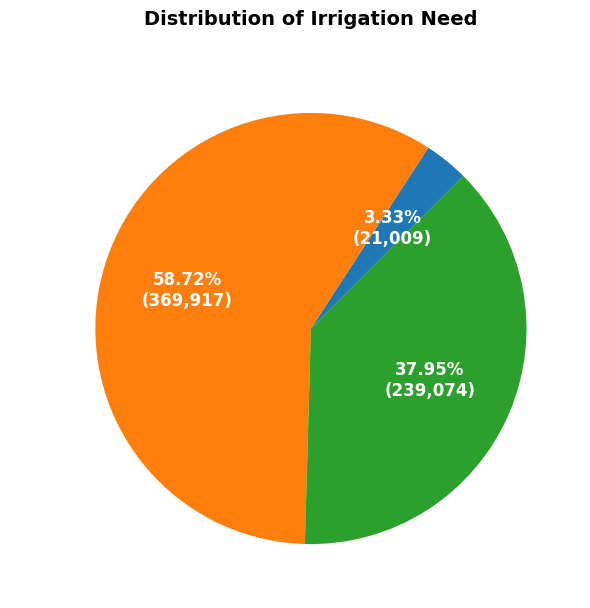

In [26]:
counts = train_data['Irrigation_Need'].value_counts().sort_index()
labels = ['Low', 'Medium', 'High']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*len(train_data)):,})', startangle=45, textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'})

plt.title("Distribution of Irrigation Need", fontsize=14, fontweight='bold', pad=25)
plt.show()

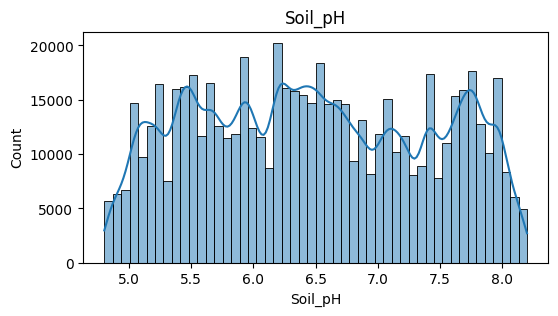

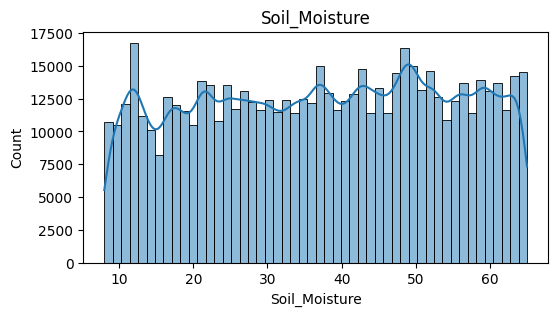

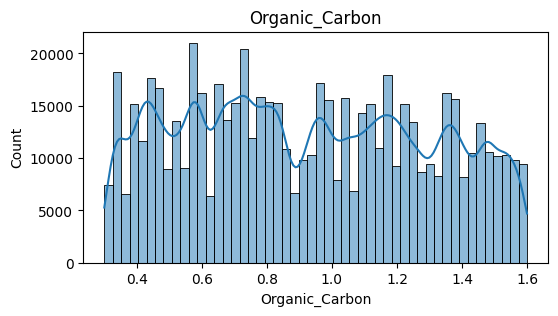

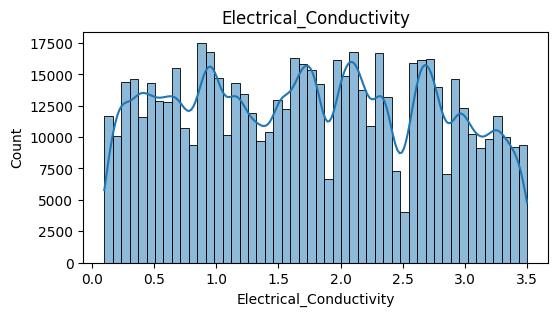

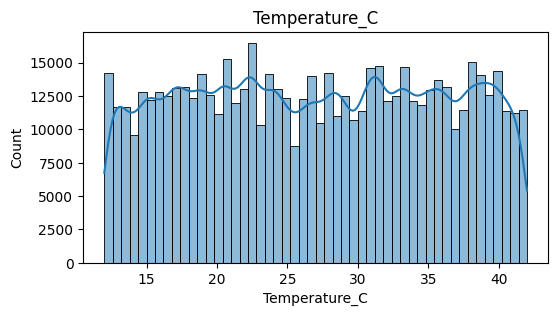

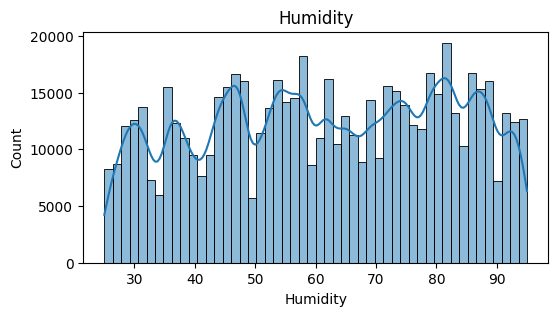

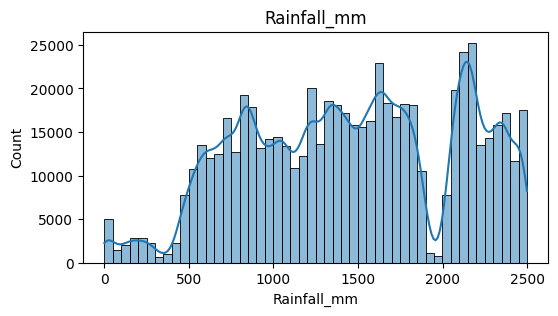

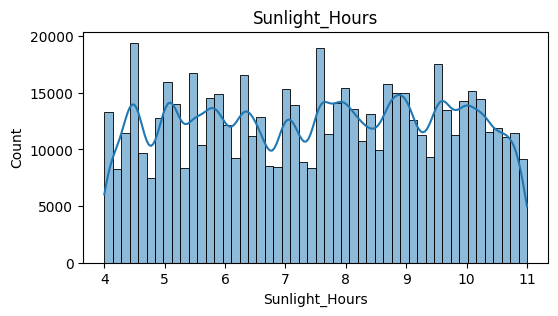

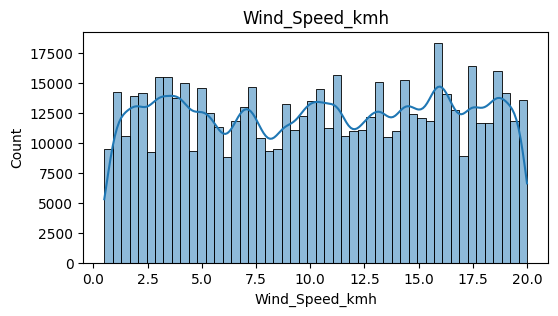

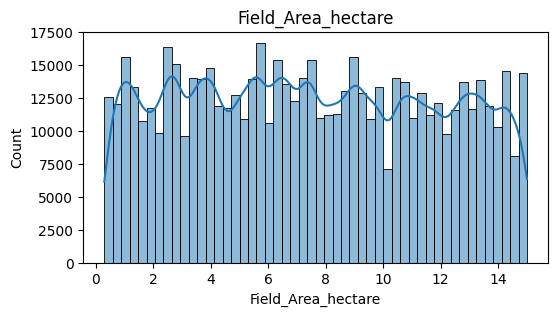

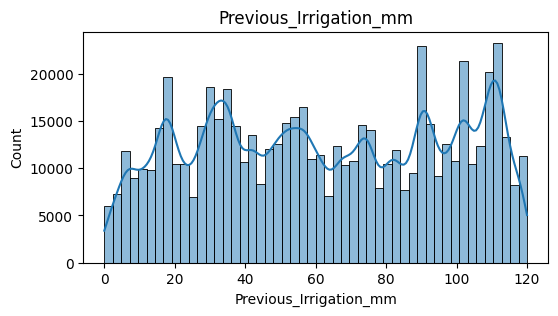

In [29]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(train_data[col], kde=True, bins=50)
    plt.title(col)
    plt.show()

Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64


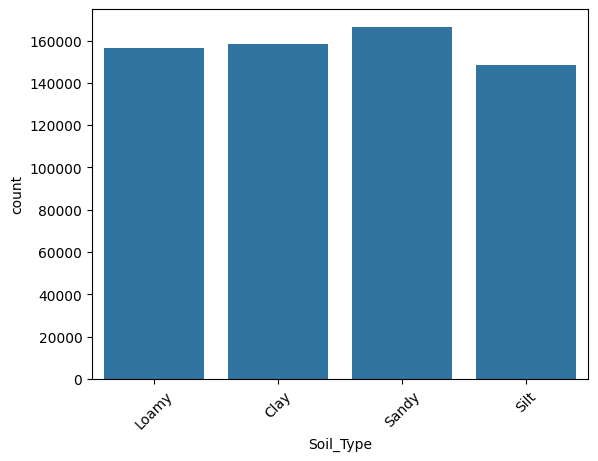

Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64


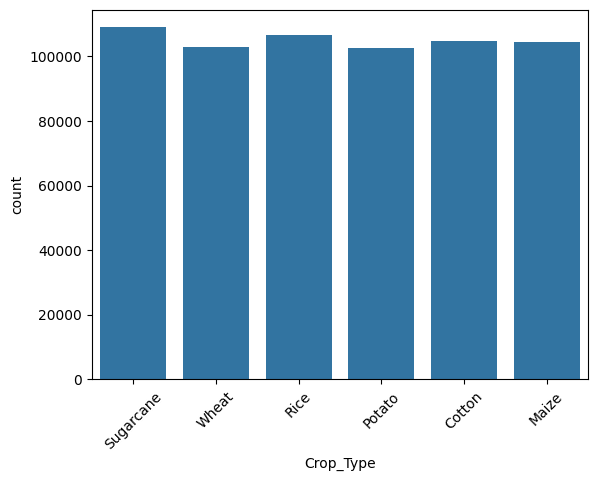

Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64


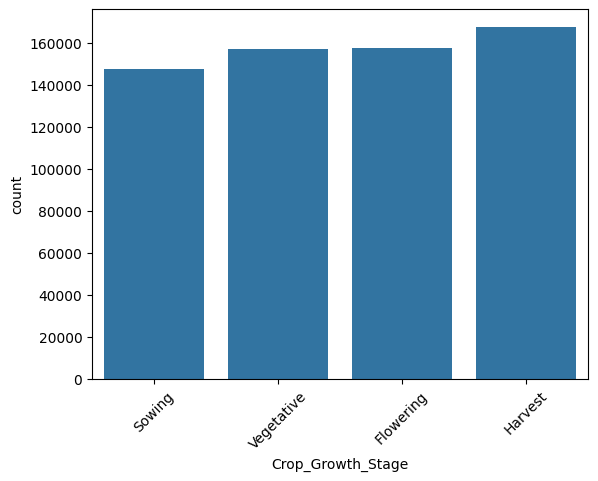

Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64


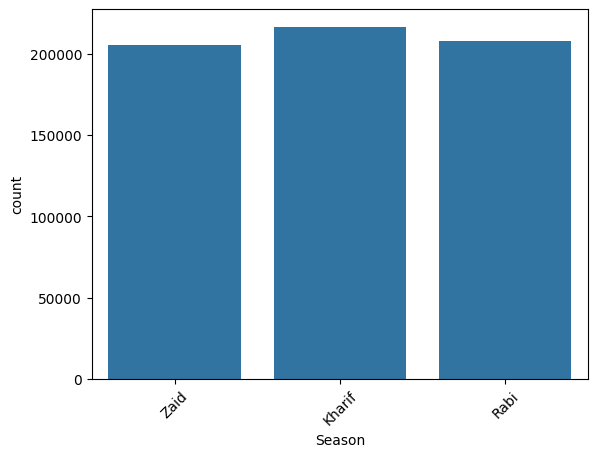

Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64


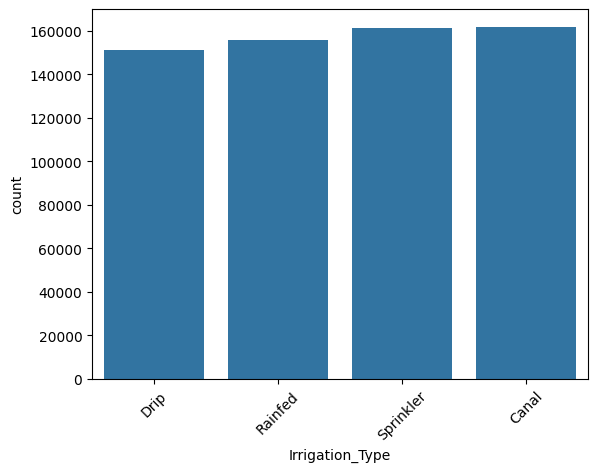

Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64


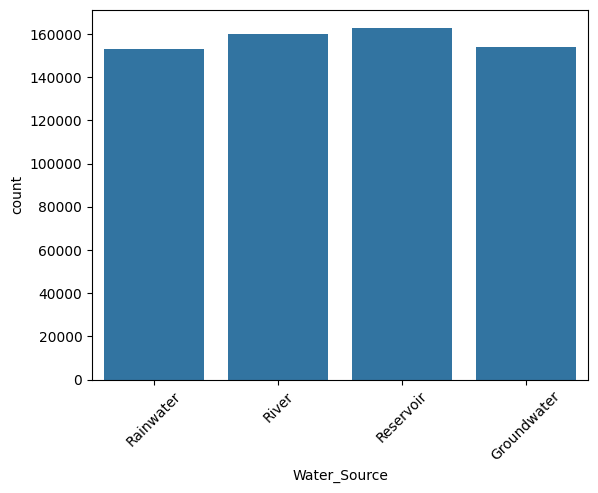

Mulching_Used
No     316453
Yes    313547
Name: count, dtype: int64


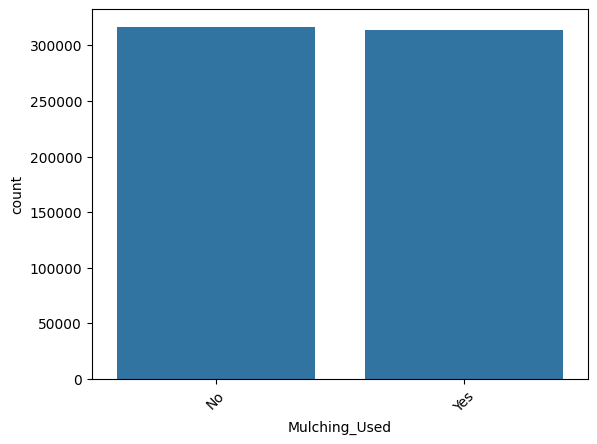

Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64


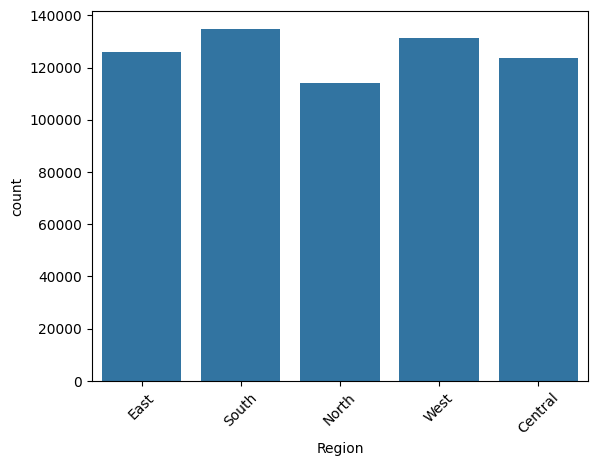

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


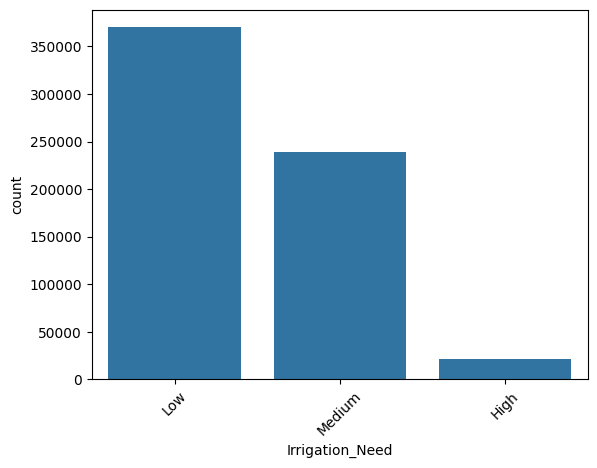

In [33]:
for col in categorical_cols:
    print(train_data[col].value_counts())
    sns.countplot(x=train_data[col])
    plt.xticks(rotation=45)
    plt.show()

Numerical Features vs Target Variable

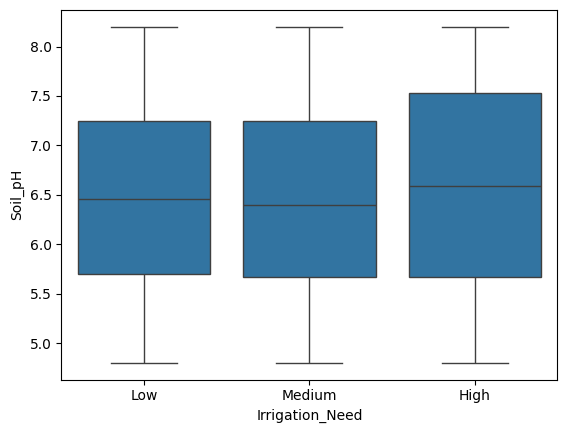

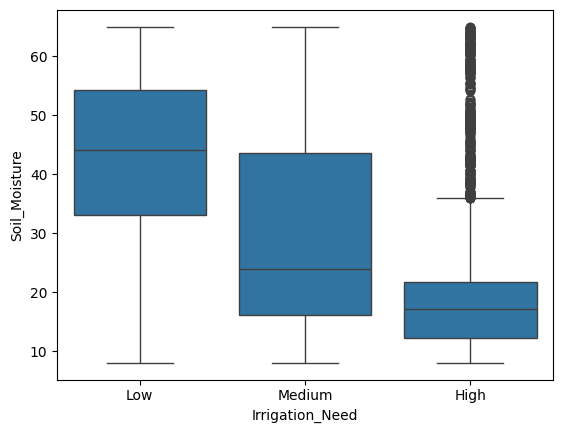

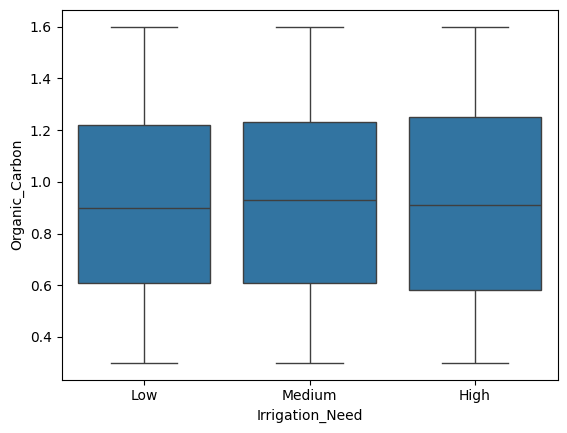

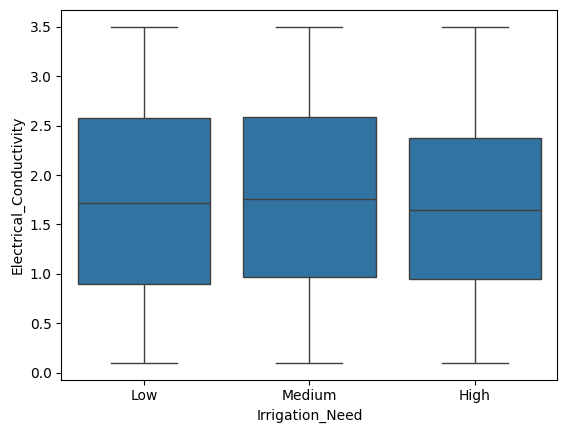

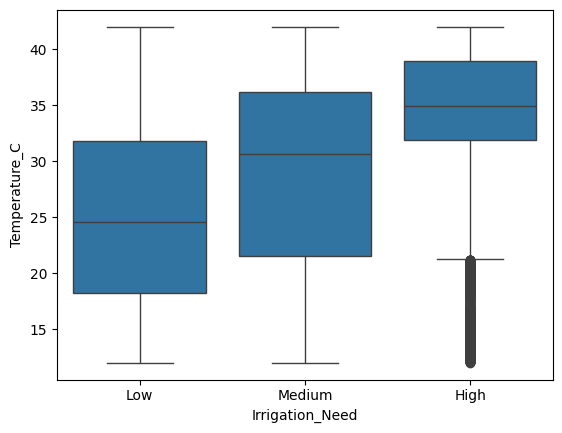

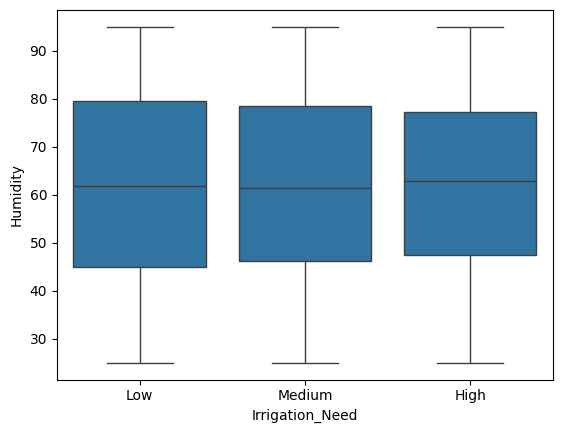

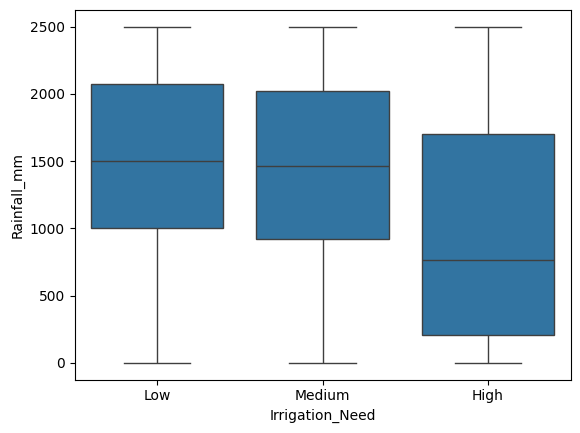

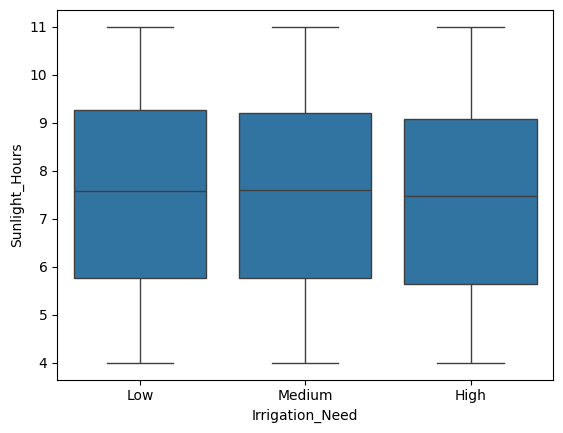

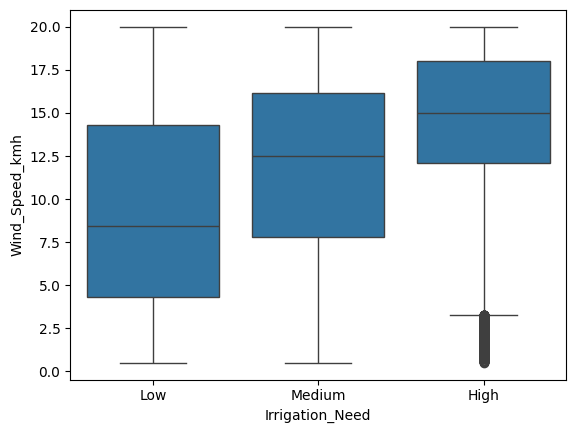

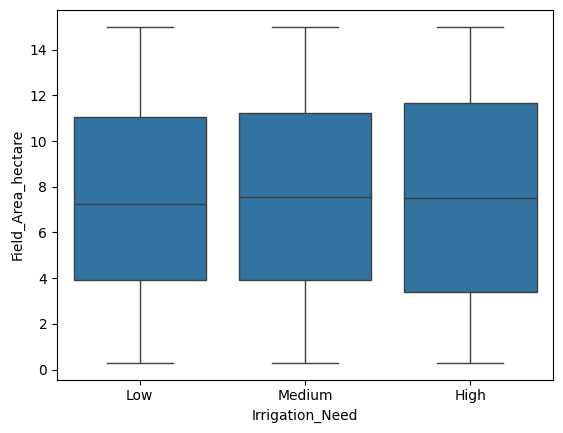

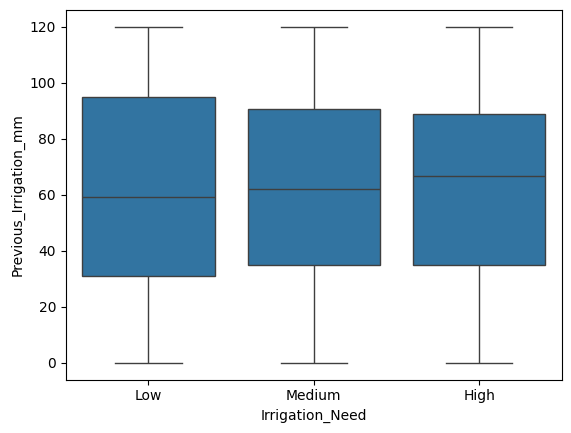

In [35]:
for col in numerical_cols:
    sns.boxplot(x='Irrigation_Need', y=col, data=train_data)
    plt.show()

Categorical Features vs Target Variable

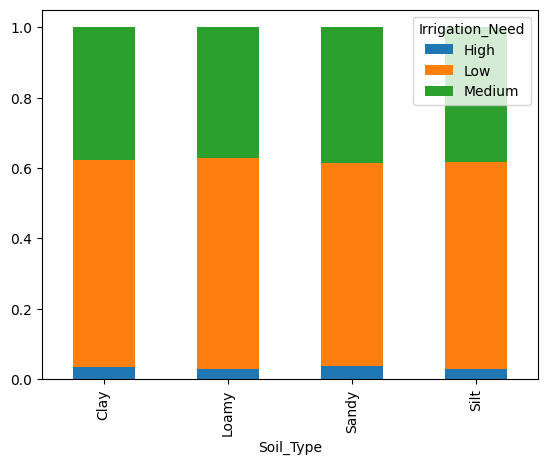

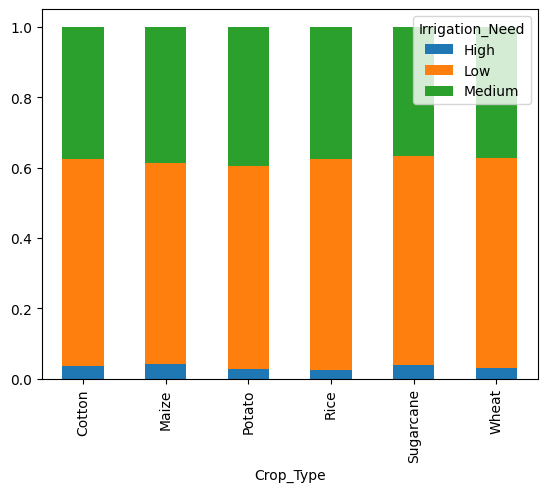

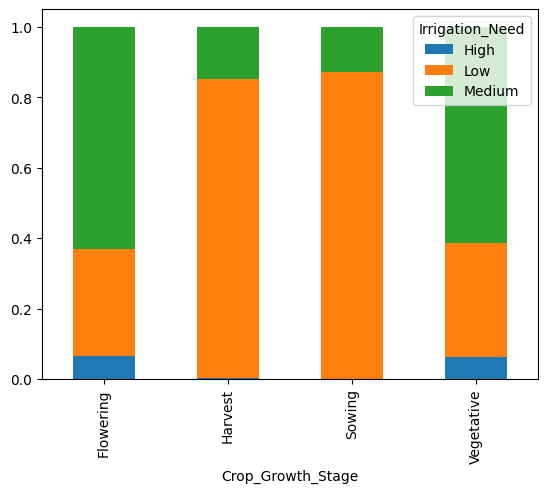

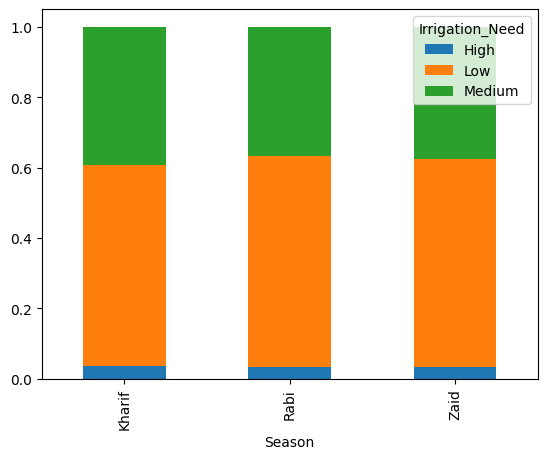

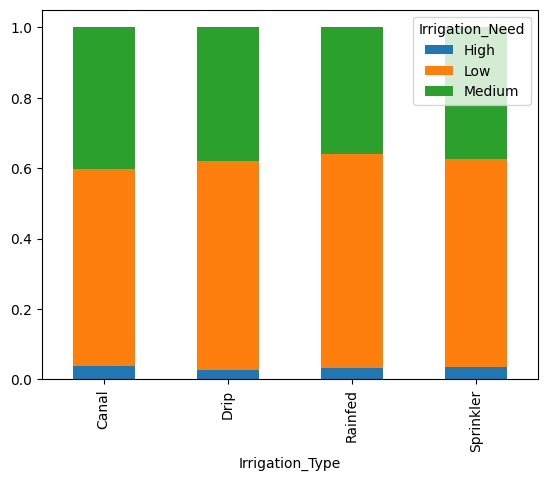

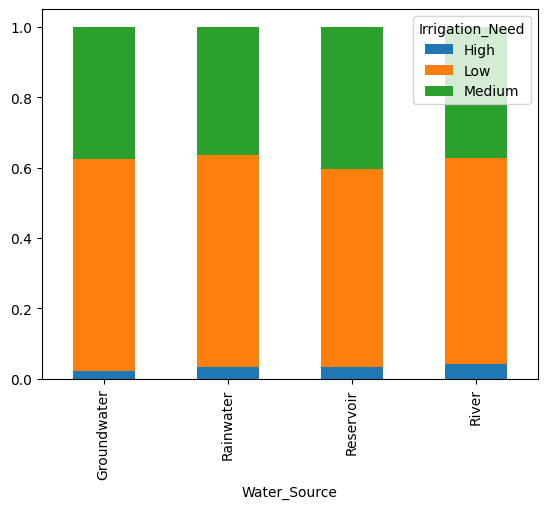

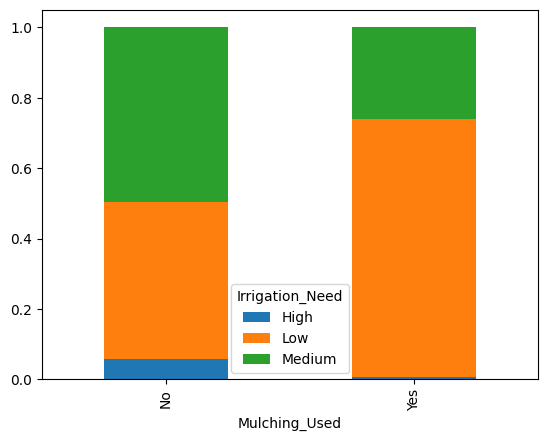

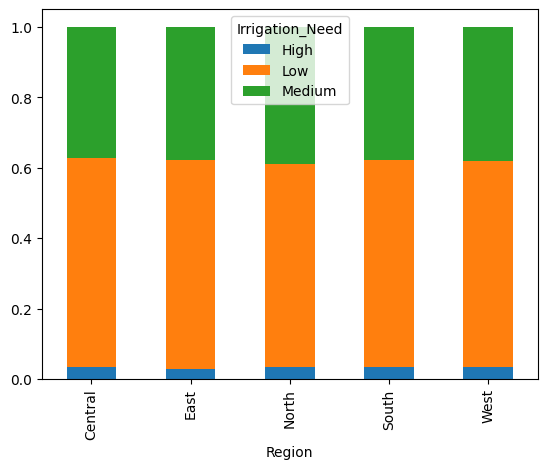

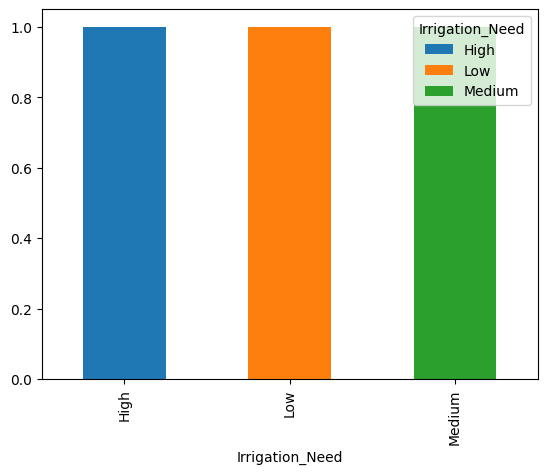

In [37]:
for col in categorical_cols:
    ct = pd.crosstab(train_data[col], train_data['Irrigation_Need'], normalize='index')
    ct.plot(kind='bar', stacked=True)
    plt.show()

Correlation Matrix

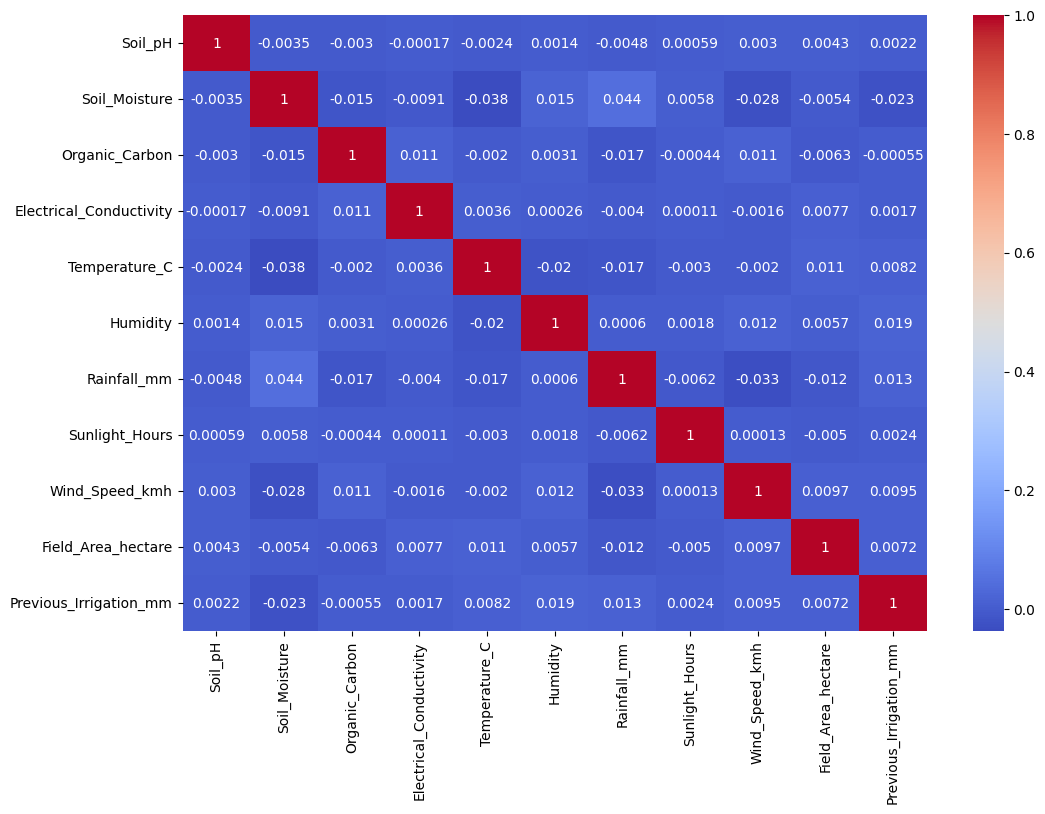

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [44]:
def cramer_v(a, b):
    confusion_matrix = pd.crosstab(a, b)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r,k = confusion_matrix.shape
    phi2 = chi2/n
    phi2corr = max(0,phi2-((k-1)*(r-1))/(n-1))
    rcorr = r - ((r - 1) ** 2) / ( n - 1 )
    kcorr = k - ((k - 1) ** 2) / ( n - 1 )

    if min((kcorr - 1),(rcorr - 1)) == 0:
        return 0
    else:
        return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

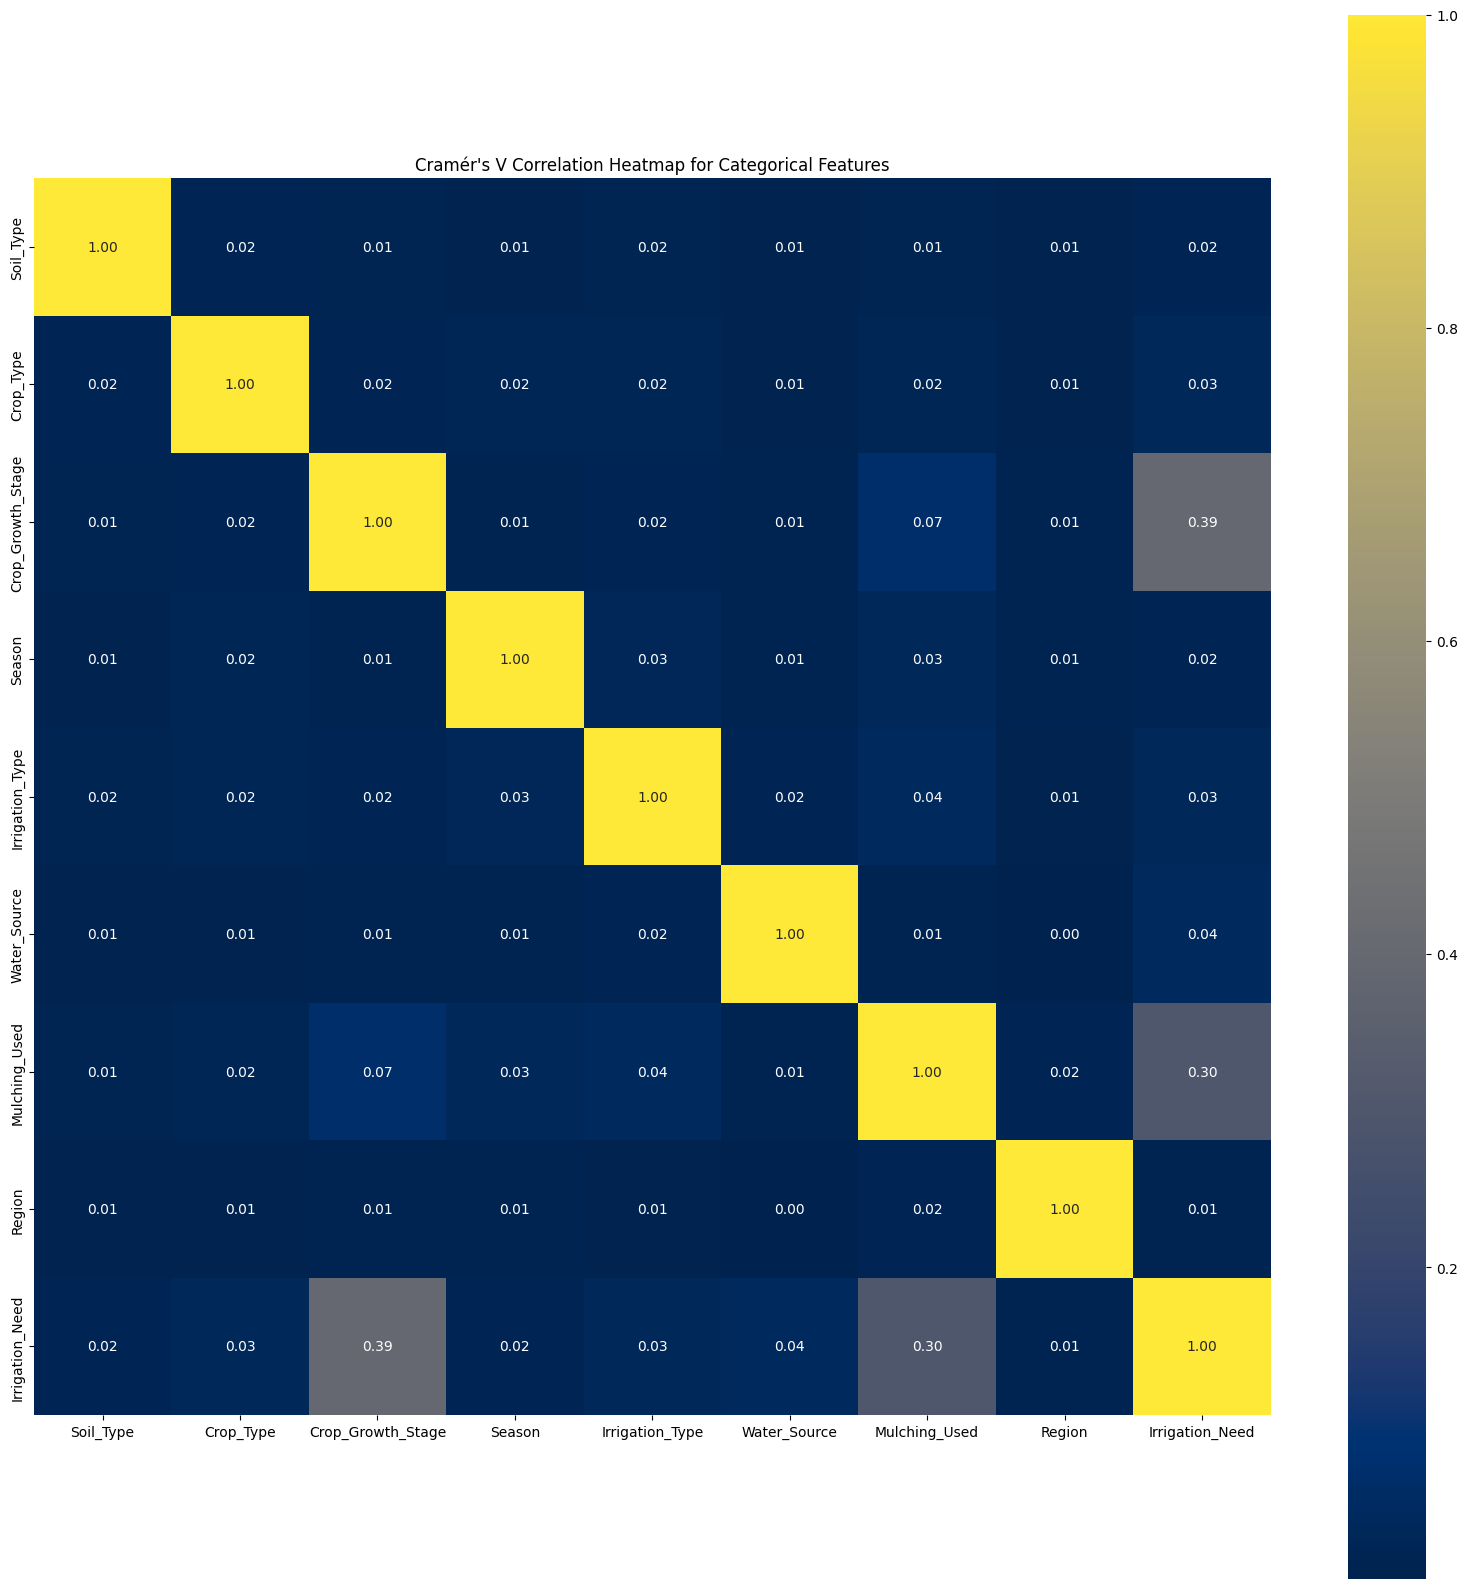

In [47]:
m = len(categorical_cols)
corr_matrix = np.zeros((m, m))
for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i == j:
            corr_matrix[i, j] = 1.0
        else:
            corr_matrix[i, j] = cramer_v(train_data[col1], train_data[col2])
            corr_matrix[j, i] = corr_matrix[i, j]

corr_df = pd.DataFrame(corr_matrix, index=categorical_cols, columns=categorical_cols)

plt.figure(figsize=(16, 16))
sns.heatmap(corr_df, annot=True, square=True, fmt='.2f', cmap='cividis')
plt.title("Cramér's V Correlation Heatmap for Categorical Features")
plt.tight_layout()
plt.show()

Feature Engineering

In [48]:
train_data['Moisture_deficit'] = train_data['Rainfall_mm'] - train_data['Previous_Irrigation_mm']